# PyTorch hooks for layerwise diagnostics

A deep network can fail while its final loss says only “something went wrong.”
Hooks let us observe tensors *inside* an existing model without rewriting its
forward method. In this tutorial we will build the hook machinery from a
two-layer worked example, then use it to measure a network with 30 hidden layers.

**Working rule:** predict what a hook will see before running each example.

The signatures used here match the current PyTorch API:

- forward hook: `hook(module, args, output)`;
- tensor gradient hook: `hook(grad)`;
- full module backward hook: `hook(module, grad_input, grad_output)`.

Official references: [module hooks](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html),
[tensor hooks](https://docs.pytorch.org/docs/stable/generated/torch.Tensor.register_hook.html), and
[leaf versus non-leaf gradients](https://docs.pytorch.org/tutorials/beginner/understanding_leaf_vs_nonleaf_tutorial.html).

In [1]:
import math
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

torch.set_num_threads(min(4, torch.get_num_threads()))
torch.manual_seed(7)

INK = "#23373B"
BLUE = "#2B6CB0"
GREEN = "#14B03D"
ORANGE = "#EB811B"
RED = "#D64550"
MUTED = "#6E7F82"

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "text.color": INK,
})

def rms(tensor):
    return tensor.detach().float().square().mean().sqrt().item()

print("PyTorch", torch.__version__)

PyTorch 2.13.0


## 1 · Prefer explicit intermediates when you own the model

If you can edit `forward`, returning the tensors you need is usually clearest:
the data flow remains visible, names are explicit, and there are no handles to
manage. Hooks are most useful for an existing model, many selected layers, or
temporary instrumentation that should not change the model's public output.

We begin with a deterministic network:

$$x\in\mathbb{R}^2 \longrightarrow z=W_1x+b_1
\longrightarrow h=\operatorname{ReLU}(z) \longrightarrow \text{logits}. $$

For `x = [2, 1]`, predict which of the three coordinates will be zero after
ReLU.

In [2]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 3)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(3, 2)

        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([
                [1.0, -1.0],
                [0.5,  0.5],
                [-1.0, 0.0],
            ]))
            self.fc1.bias.copy_(torch.tensor([0.0, -1.0, 0.5]))
            self.fc2.weight.copy_(torch.tensor([
                [1.0, 0.0, -1.0],
                [-0.5, 1.0, 0.5],
            ]))
            self.fc2.bias.copy_(torch.tensor([0.0, 0.25]))

    def forward(self, x, return_intermediates=False):
        z = self.fc1(x)
        h = self.relu(z)
        logits = self.fc2(h)
        if return_intermediates:
            return logits, {"z": z, "h": h}
        return logits


model = TinyMLP()
x = torch.tensor([[2.0, 1.0], [-1.0, 2.0]])
logits, intermediates = model(x, return_intermediates=True)

print("x =\n", x)
print("z = W1 x + b1 =\n", intermediates["z"].detach())
print("h = ReLU(z) =\n", intermediates["h"].detach())
print("logits =\n", logits.detach())

expected_z = torch.tensor([[1.0, 0.5, -1.5], [-3.0, -0.5, 1.5]])
expected_h = torch.tensor([[1.0, 0.5, 0.0], [0.0, 0.0, 1.5]])
assert torch.equal(intermediates["z"].detach(), expected_z)
assert torch.equal(intermediates["h"].detach(), expected_h)

x =
 tensor([[ 2.,  1.],
        [-1.,  2.]])
z = W1 x + b1 =
 tensor([[ 1.0000,  0.5000, -1.5000],
        [-3.0000, -0.5000,  1.5000]])
h = ReLU(z) =
 tensor([[1.0000, 0.5000, 0.0000],
        [0.0000, 0.0000, 1.5000]])
logits =
 tensor([[ 1.0000,  0.2500],
        [-1.5000,  1.0000]])


## 2 · One forward hook

`register_forward_hook` runs *after* a module computes its output. The hook
receives the module, a tuple of positional arguments, and the output. It returns
a removable handle.

Predict: if we attach the hook to `fc1`, will it store $z$ or $h$?

In [3]:
saved = {}

def save_fc1_output(module, args, output):
    assert module is model.fc1
    assert isinstance(args, tuple) and len(args) == 1
    saved["fc1"] = output.detach().clone()
    # Returning None leaves the model output unchanged.


handle = model.fc1.register_forward_hook(save_fc1_output)
plain_logits = model(x)

print("hook signature: (module, args, output)")
print("stored fc1 output =\n", saved["fc1"])
print("handle type:", type(handle).__name__)

assert torch.equal(saved["fc1"], expected_z)
assert torch.equal(plain_logits, logits)

handle.remove()
saved.clear()
_ = model(x)
print("after handle.remove(), saved =", saved)
assert saved == {}

hook signature: (module, args, output)
stored fc1 output =
 tensor([[ 1.0000,  0.5000, -1.5000],
        [-3.0000, -0.5000,  1.5000]])
handle type: RemovableHandle
after handle.remove(), saved = {}


## 3 · The module you hook determines the tensor you see

The linear layer produces the **preactivation** $z$. The ReLU module produces
the **post-activation** $h$. Calling both “the activation” hides an important
difference: negative entries exist in $z$ and have already become zero in $h$.

Predict the two heatmaps before running the cell.

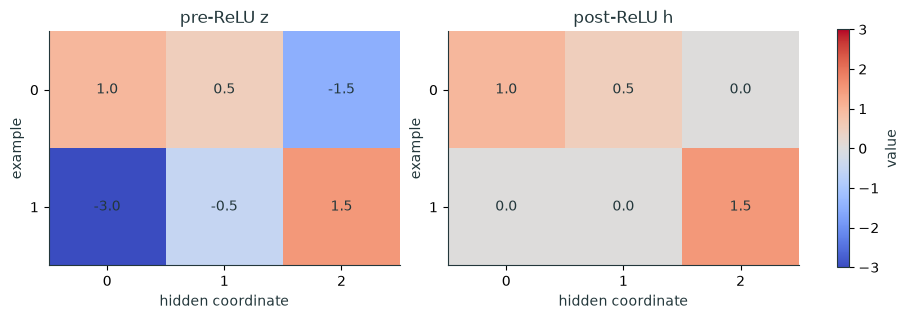

In [4]:
seen = {}

def make_capture(name):
    def hook(module, args, output):
        seen[name] = output.detach().clone()
    return hook


handles = [
    model.fc1.register_forward_hook(make_capture("pre-ReLU z")),
    model.relu.register_forward_hook(make_capture("post-ReLU h")),
]
_ = model(x)
for hook_handle in handles:
    hook_handle.remove()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
for ax, name in zip(axes, ("pre-ReLU z", "post-ReLU h")):
    values = seen[name].numpy()
    image = ax.imshow(values, cmap="coolwarm", vmin=-3, vmax=3)
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            ax.text(col, row, f"{values[row, col]:.1f}", ha="center", va="center")
    ax.set_title(name)
    ax.set_xlabel("hidden coordinate")
    ax.set_ylabel("example")
    ax.set_xticks(range(3)); ax.set_yticks(range(2))
fig.colorbar(image, ax=axes, shrink=0.8, label="value")
plt.show()

assert torch.equal(seen["pre-ReLU z"], expected_z)
assert torch.equal(seen["post-ReLU h"], expected_h)

## 4 · Register several named layers safely

Hooks are often created in a loop. Bind each layer name when the hook is
created. A late-bound `lambda` may otherwise make every hook write under the
last name in the loop.

We keep the handles together so cleanup is one short loop.

In [5]:
def capture_named_output(name, store):
    # `name` is fixed in this closure when the factory is called.
    def hook(module, args, output):
        if not isinstance(output, torch.Tensor):
            raise TypeError(f"{name} returned {type(output).__name__}, not a Tensor")
        store[name] = output.detach().clone()
    return hook


layer_outputs = {}
named_handles = []
selected = {"fc1", "relu", "fc2"}
for name, module in model.named_modules():
    if name in selected:
        named_handles.append(
            module.register_forward_hook(capture_named_output(name, layer_outputs))
        )

_ = model(x)
for name, value in layer_outputs.items():
    print(f"{name:4s} shape={tuple(value.shape)} RMS={rms(value):.4f}")

assert list(layer_outputs) == ["fc1", "relu", "fc2"]
assert torch.equal(layer_outputs["fc1"], expected_z)
assert torch.equal(layer_outputs["relu"], expected_h)

for hook_handle in named_handles:
    hook_handle.remove()
layer_outputs.clear()

fc1  shape=(2, 3) RMS=1.5811
relu shape=(2, 3) RMS=0.7638
fc2  shape=(2, 2) RMS=1.0383


## 5 · Why an intermediate tensor's `.grad` is usually `None`

Parameters are leaf tensors, so their `.grad` fields are populated by
`backward()`. An activation such as $h$ is a **non-leaf** tensor. Autograd
computes $\partial L/\partial h$ on its way backward, but does not keep it in
`h.grad` by default.

Predict the values of `h.is_leaf` and `h.grad` below.

In [6]:
model.zero_grad(set_to_none=True)
logits_default, parts_default = model(x, return_intermediates=True)
h_default = parts_default["h"]
loss_default = logits_default.square().mean()
loss_default.backward()

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    default_grad = h_default.grad

print("h.requires_grad:", h_default.requires_grad)
print("h.is_leaf:", h_default.is_leaf)
print("h.grad after backward:", default_grad)
print("captured warning mentions retain_grad:", "retain_grad" in str(caught[0].message))

assert h_default.requires_grad and not h_default.is_leaf
assert default_grad is None
assert caught and "retain_grad" in str(caught[0].message)

h.requires_grad: True
h.is_leaf: False
h.grad after backward: None
captured warning mentions retain_grad: True


Call `retain_grad()` on a particular non-leaf tensor *before* `backward()` when
you truly want its complete gradient tensor stored in `.grad`. This is useful
for a small worked example, but retaining every activation gradient in a large
network consumes memory.

In [7]:
model.zero_grad(set_to_none=True)
logits_retained, parts_retained = model(x, return_intermediates=True)
h_retained = parts_retained["h"]
h_retained.retain_grad()
loss_retained = logits_retained.square().mean()
loss_retained.backward()

print("retained dL/dh =\n", h_retained.grad)
print("gradient RMS =", round(rms(h_retained.grad), 6))

assert h_retained.grad is not None
assert h_retained.grad.shape == h_retained.shape
assert torch.isfinite(h_retained.grad).all()

retained dL/dh =
 tensor([[ 0.4375,  0.1250, -0.4375],
        [-1.0000,  0.5000,  1.0000]])
gradient RMS = 0.664384


## 6 · Prefer a tensor hook when you need only a summary of $\partial L/\partial h$

`Tensor.register_hook` receives the gradient as soon as autograd computes it.
The hook below records one detached Python number and returns `None`, so it does
not keep the computation graph and does not alter the gradient.

This is usually the cleanest choice for activation-gradient diagnostics.

In [8]:
model.zero_grad(set_to_none=True)
logits_tensor_hook, parts_tensor_hook = model(x, return_intermediates=True)
h_tensor_hook = parts_tensor_hook["h"]
gradient_summary = {}

def record_h_gradient(grad):
    gradient_summary["shape"] = tuple(grad.shape)
    gradient_summary["rms"] = rms(grad)
    gradient_summary["finite"] = bool(torch.isfinite(grad).all())
    # None means: observe the gradient, do not replace it.


tensor_handle = h_tensor_hook.register_hook(record_h_gradient)
logits_tensor_hook.square().mean().backward()
tensor_handle.remove()

print(gradient_summary)
with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    unretained_grad = h_tensor_hook.grad
print("h.grad is still", unretained_grad)

assert gradient_summary["shape"] == tuple(h_tensor_hook.shape)
assert gradient_summary["finite"]
assert unretained_grad is None

{'shape': (2, 3), 'rms': 0.664384126663208, 'finite': True}
h.grad is still None


## 7 · How a full module backward hook differs

`register_full_backward_hook` receives **tuples**:

- `grad_output`: gradients with respect to the module's outputs;
- `grad_input`: gradients with respect to its positional inputs.

For our ReLU, `grad_output[0]` is $\partial L/\partial h$ and
`grad_input[0]` is $\partial L/\partial z$. A tensor hook on `h` sees the same
gradient as `grad_output[0]`, with less module-specific bookkeeping.

Never use the deprecated `register_backward_hook`.

In [9]:
module_backward = {}
tensor_backward = {}
temporary_tensor_handles = []

def attach_tensor_hook(module, args, output):
    temporary_tensor_handles.append(
        output.register_hook(lambda grad: tensor_backward.setdefault("dL_dh", grad.detach().clone()))
    )

def inspect_full_backward(module, grad_input, grad_output):
    module_backward["grad_input_types"] = tuple(type(g).__name__ for g in grad_input)
    module_backward["grad_output_types"] = tuple(type(g).__name__ for g in grad_output)
    module_backward["dL_dz"] = grad_input[0].detach().clone()
    module_backward["dL_dh"] = grad_output[0].detach().clone()


forward_handle = model.relu.register_forward_hook(attach_tensor_hook)
full_backward_handle = model.relu.register_full_backward_hook(inspect_full_backward)

model.zero_grad(set_to_none=True)
x_with_grad = x.clone().requires_grad_(True)
model(x_with_grad).square().mean().backward()

forward_handle.remove()
full_backward_handle.remove()
for hook_handle in temporary_tensor_handles:
    hook_handle.remove()

print("grad_input tuple types:", module_backward["grad_input_types"])
print("grad_output tuple types:", module_backward["grad_output_types"])
print("RMS dL/dz:", round(rms(module_backward["dL_dz"]), 6))
print("RMS dL/dh:", round(rms(module_backward["dL_dh"]), 6))
print("tensor hook == grad_output[0]:",
      torch.equal(tensor_backward["dL_dh"], module_backward["dL_dh"]))

assert isinstance(module_backward["grad_input_types"], tuple)
assert isinstance(module_backward["grad_output_types"], tuple)
assert torch.equal(tensor_backward["dL_dh"], module_backward["dL_dh"])
assert torch.equal(
    module_backward["dL_dz"],
    module_backward["dL_dh"] * (seen["pre-ReLU z"] > 0),
)

grad_input tuple types: ('Tensor',)
grad_output tuple types: ('Tensor',)
RMS dL/dz: 0.448522
RMS dL/dh: 0.664384
tensor hook == grad_output[0]: True


## 8 · Lifecycle rules that prevent subtle bugs

1. Save every handle and remove it when the measurement is finished.
2. Clear stores between batches; otherwise stale values look current.
3. Store detached tensors or scalar summaries, not graph-connected outputs.
4. `model.eval()` changes layers such as dropout and BatchNorm; it does **not**
   disable autograd.
5. `torch.no_grad()` disables graph construction; forward hooks still fire,
   but their outputs cannot accept tensor gradient hooks.
6. Observe outputs. Do not modify them, and avoid in-place operations around
   backward hooks.

In [10]:
forward_events = []

def record_context(module, args, output):
    forward_events.append({
        "training": module.training,
        "grad_enabled": torch.is_grad_enabled(),
        "output_requires_grad": output.requires_grad,
    })


context_handle = model.relu.register_forward_hook(record_context)
model.eval()
_ = model(x)                       # eval mode, autograd still enabled
with torch.no_grad():
    _ = model(x)                   # eval mode, no graph
context_handle.remove()
model.train()

print("eval with autograd: ", forward_events[0])
print("eval with no_grad():", forward_events[1])

assert forward_events[0] == {
    "training": False, "grad_enabled": True, "output_requires_grad": True
}
assert forward_events[1] == {
    "training": False, "grad_enabled": False, "output_requires_grad": False
}

eval with autograd:  {'training': False, 'grad_enabled': True, 'output_requires_grad': True}
eval with no_grad(): {'training': False, 'grad_enabled': False, 'output_requires_grad': False}


## 9 · Reused modules and structured outputs

A module hook fires once per **call**, not once per module object. If the same
module is reused twice, expect two events. Also, a module may return a tuple,
list, or dictionary; do not blindly call `.detach()` on the whole output.

The helper below walks a small output tree without changing it.

In [11]:
def tensor_leaves(value):
    if isinstance(value, torch.Tensor):
        return [value]
    if isinstance(value, dict):
        leaves = []
        for item in value.values():
            leaves.extend(tensor_leaves(item))
        return leaves
    if isinstance(value, (tuple, list)):
        leaves = []
        for item in value:
            leaves.extend(tensor_leaves(item))
        return leaves
    return []


class ReuseOneModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()

    def forward(self, value):
        return self.relu(value - 1), self.relu(value + 1)


class ListOutput(nn.Module):
    def forward(self, value):
        return [value, value.square()]


reuse = ReuseOneModule()
calls = []
reuse_handle = reuse.relu.register_forward_hook(
    lambda module, args, output: calls.append(output.detach().clone())
)
_ = reuse(torch.tensor([[-2.0, 2.0]]))
reuse_handle.remove()

structured = {}
list_module = ListOutput()
list_handle = list_module.register_forward_hook(
    lambda module, args, output: structured.update(
        leaf_shapes=[tuple(t.shape) for t in tensor_leaves(output)]
    )
)
list_result = list_module(torch.ones(2, 3))
list_handle.remove()

print("same ReLU object, number of calls:", len(calls))
print("structured output type:", type(list_result).__name__)
print("tensor leaf shapes:", structured["leaf_shapes"])

assert len(calls) == 2
assert isinstance(list_result, list)
assert structured["leaf_shapes"] == [(2, 3), (2, 3)]

same ReLU object, number of calls: 2
structured output type: list
tensor leaf shapes: [(2, 3), (2, 3)]


## 10 · A 30-hidden-layer diagnostic

Now we instrument every post-ReLU tensor in a deep MLP. The experiment keeps
the architecture, input batch, labels, and random weight directions fixed. It
changes only a multiplier $\alpha$ applied to the 30 hidden He-initialized
weight matrices. This compact hooks example keeps its classifier fixed; the
lecture's spiral experiment scales all 31 weight matrices.

For every hidden layer we will record:

- activation RMS;
- fraction of positive post-ReLU entries;
- whether every activation is finite;
- activation-gradient RMS, with $G_\ell=\partial L/\partial H_\ell$ for the batch tensor $H_\ell$.

Predict the depth traces for $\alpha\in\{0.5, 1.0, 1.5\}$.

In [12]:
class DeepReLUMlp(nn.Module):
    def __init__(self, alpha, depth=30, width=64, seed=19):
        super().__init__()
        torch.manual_seed(seed)
        self.blocks = nn.ModuleList()
        incoming = 32
        for _ in range(depth):
            linear = nn.Linear(incoming, width)
            nn.init.normal_(linear.weight, mean=0.0, std=math.sqrt(2 / incoming))
            nn.init.zeros_(linear.bias)
            with torch.no_grad():
                linear.weight.mul_(alpha)
            self.blocks.append(nn.Sequential(linear, nn.ReLU()))
            incoming = width
        self.classifier = nn.Linear(width, 4)
        nn.init.normal_(self.classifier.weight, mean=0.0, std=math.sqrt(1 / width))
        nn.init.zeros_(self.classifier.bias)

    def forward(self, value):
        for block in self.blocks:
            value = block(value)
        return self.classifier(value)


data_generator = torch.Generator().manual_seed(23)
deep_x = torch.randn(256, 32, generator=data_generator)
deep_y = torch.randint(0, 4, (256,), generator=data_generator)

deep_models = {alpha: DeepReLUMlp(alpha) for alpha in (0.5, 1.0, 1.5)}
reference = deep_models[1.0].blocks[9][0].weight.detach()
assert torch.equal(deep_models[0.5].blocks[9][0].weight.detach(), 0.5 * reference)
assert torch.allclose(deep_models[1.5].blocks[9][0].weight.detach(), 1.5 * reference)

print("batch:", tuple(deep_x.shape), "labels:", tuple(deep_y.shape))
print("30 Linear → ReLU blocks; identical base directions for all alpha")

batch: (256, 32) labels: (256,)
30 Linear → ReLU blocks; identical base directions for all alpha


The forward hook below records detached forward statistics, then attaches a
tensor hook to that *specific output tensor*. The tensor hook stores only a
Python float for the backward RMS. Module handles and per-forward tensor
handles are both removed in `finally`, even if the diagnostic raises an error.

In [13]:
def diagnose_hidden_relus(model, inputs, targets):
    rows = {}
    module_handles = []
    tensor_handles = []

    def make_layer_hook(layer_index):
        def forward_hook(module, args, output):
            if not isinstance(output, torch.Tensor):
                raise TypeError(f"layer {layer_index} returned a non-Tensor")
            rows[layer_index] = {
                "layer": layer_index,
                "activation_rms": rms(output),
                "active_fraction": output.detach().gt(0).float().mean().item(),
                "activations_finite": bool(torch.isfinite(output).all()),
            }
            if output.requires_grad:
                def record_gradient(grad, index=layer_index):
                    rows[index]["gradient_rms"] = rms(grad)
                    rows[index]["gradients_finite"] = bool(torch.isfinite(grad).all())
                tensor_handles.append(output.register_hook(record_gradient))
        return forward_hook

    try:
        for index, block in enumerate(model.blocks, start=1):
            module_handles.append(block[1].register_forward_hook(make_layer_hook(index)))

        model.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = F.cross_entropy(logits, targets)
        loss.backward()
    finally:
        for hook_handle in module_handles:
            hook_handle.remove()
        for hook_handle in tensor_handles:
            hook_handle.remove()

    ordered = [rows[index] for index in sorted(rows)]
    assert len(ordered) == len(model.blocks) == 30
    assert all("gradient_rms" in row for row in ordered)
    return ordered, loss.detach().item()


diagnostics = {}
for alpha, deep_model in deep_models.items():
    diagnostics[alpha], loss_value = diagnose_hidden_relus(deep_model, deep_x, deep_y)
    first, last = diagnostics[alpha][0], diagnostics[alpha][-1]
    print(
        f"alpha={alpha:.1f}  loss={loss_value:9.4g}  "
        f"activation RMS L1→L30: {first['activation_rms']:.3g} → {last['activation_rms']:.3g}  "
        f"gradient RMS L1→L30: {first['gradient_rms']:.3g} → {last['gradient_rms']:.3g}"
    )

alpha=0.5  loss=    1.386  activation RMS L1→L30: 0.498 → 7.43e-10  gradient RMS L1→L30: 4.97e-13 → 0.00038
alpha=1.0  loss=    1.619  activation RMS L1→L30: 0.997 → 0.798  gradient RMS L1→L30: 0.000305 → 0.000405
alpha=1.5  loss=1.633e+05  activation RMS L1→L30: 1.49 → 1.53e+05  gradient RMS L1→L30: 51 → 0.000542


The plot is the payoff: a local scale multiplier is composed across depth.
The active fraction alone stays near one half and therefore cannot diagnose
signal magnitude. We need the measurements together.

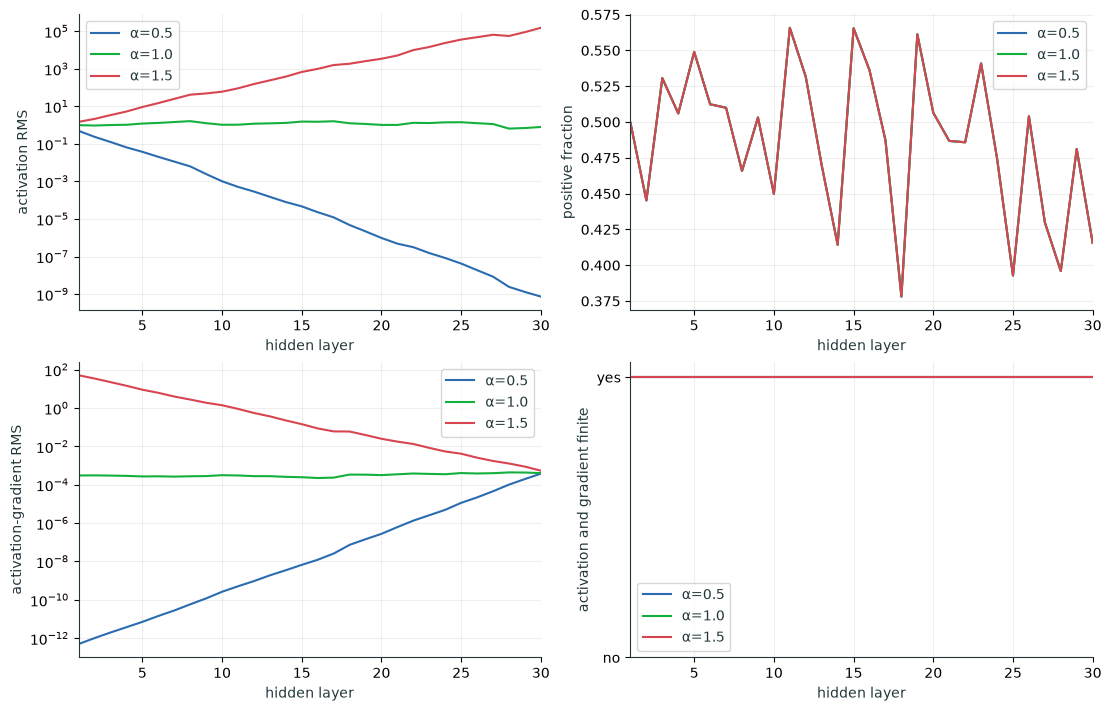

In [14]:
colors = {0.5: BLUE, 1.0: GREEN, 1.5: RED}
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

for alpha, rows in diagnostics.items():
    layers = [row["layer"] for row in rows]
    axes[0, 0].plot(layers, [row["activation_rms"] for row in rows],
                    color=colors[alpha], label=f"α={alpha}")
    axes[0, 1].plot(layers, [row["active_fraction"] for row in rows],
                    color=colors[alpha], label=f"α={alpha}")
    axes[1, 0].plot(layers, [row["gradient_rms"] for row in rows],
                    color=colors[alpha], label=f"α={alpha}")
    finite = [row["activations_finite"] and row["gradients_finite"] for row in rows]
    axes[1, 1].plot(layers, finite, color=colors[alpha], label=f"α={alpha}")

axes[0, 0].set_yscale("log")
axes[1, 0].set_yscale("log")
axes[0, 0].set_ylabel("activation RMS")
axes[0, 1].set_ylabel("positive fraction")
axes[1, 0].set_ylabel("activation-gradient RMS")
axes[1, 1].set_ylabel("activation and gradient finite")
axes[1, 1].set_yticks([0, 1], labels=["no", "yes"])
for ax in axes.flat:
    ax.set_xlabel("hidden layer")
    ax.set_xlim(1, 30)
    ax.grid(alpha=0.2)
    ax.legend()
plt.show()

for alpha, rows in diagnostics.items():
    assert all(row["activations_finite"] for row in rows)
    assert all(row["gradients_finite"] for row in rows)
    assert all(0 <= row["active_fraction"] <= 1 for row in rows)
    assert all(row["activation_rms"] >= 0 for row in rows)
    assert all(row["gradient_rms"] >= 0 for row in rows)

## Checklist

Before trusting a hook-based diagnostic:

- [ ] Hook the module that produces the tensor you mean: Linear gives $z$;
  ReLU gives $h$.
- [ ] Bind names safely when registering in a loop.
- [ ] Save every removable handle and remove it.
- [ ] Clear stores between forwards.
- [ ] Store detached tensors or scalar summaries.
- [ ] Use `retain_grad()` only when you need a non-leaf tensor's full `.grad`.
- [ ] Prefer `Tensor.register_hook` for $\partial L/\partial h$ summaries.
- [ ] Treat full backward hook inputs and outputs as tuples.
- [ ] Remember that reused modules fire once per call and outputs can be nested.
- [ ] Test both the measurement and the cleanup path.

### Exercises

1. Hook `fc2` and verify that its output equals the model's logits.
2. Change the first input from `[2, 1]` to `[1, 2]`. Predict $z$, $h$, and
   $\partial L/\partial h$ before running.
3. Add `BatchNorm1d(64)` between every deep linear layer and ReLU. Compare the
   four depth traces at $\alpha=0.5$.
4. Reuse one ReLU module in all 30 blocks. Modify the collector so call index,
   not module name, identifies depth.

In [15]:
# Final integrity checks for the executed tutorial.
assert not saved
assert not layer_outputs
assert len(forward_events) == 2
assert len(diagnostics) == 3
assert all(len(rows) == 30 for rows in diagnostics.values())
assert all(
    set(row) == {
        "layer", "activation_rms", "active_fraction", "activations_finite",
        "gradient_rms", "gradients_finite",
    }
    for rows in diagnostics.values()
    for row in rows
)
print("All tutorial assertions passed.")

All tutorial assertions passed.
